In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

In [2]:
import pycbc
import pickle
import pycbc.psd
import numpy as np
import multiprocessing
from scipy.special import expit
import matplotlib.pyplot as plt
from scipy.signal import windows
from scipy.fft import rfft, rfftfreq
from mpl_toolkits.mplot3d import Axes3D
from pycbc.waveform import get_td_waveform
from scipy.interpolate import UnivariateSpline, RectBivariateSpline
from modules.gw_utils import Planck_window_LAL, planck_taper

In [3]:
def generate_fd_waveform(params, f_lower, delta_t, window_type='lal_planck', padding_type='power_of_2', epsilon=0.1, num_extrema_start=2, num_extrema_end=2):
    q = params['q']
    chi = params['chi']
    M_total = 40.0
    m2 = M_total / (1 + q)
    m1 = q * M_total / (1 + q)


    hp, _ = get_td_waveform(approximant='SEOBNRv4_opt',
                                mass1=m1, mass2=m2,
                                spin1z=chi, spin2z=chi,
                                delta_t=delta_t,
                                f_lower=f_lower)
    h_td_raw = hp.numpy()

    if window_type == "tukey":
        window = windows.tukey(len(h_td_raw), alpha=0.1)
    elif window_type == "planck":
        window = planck_taper(len(h_td_raw), epsilon=epsilon)
    elif window_type == "lal_planck":
        window = Planck_window_LAL(h_td_raw, taper_method='LAL_SIM_INSPIRAL_TAPER_STARTEND', num_extrema_start=num_extrema_start, num_extrema_end=num_extrema_end) 
    else:
        window = np.ones(len(h_td_raw))

    h_td_windowed = h_td_raw * window
    
    L = len(h_td_windowed)
    
    if padding_type == "power_of_2":
      nfft = 2 ** int(np.ceil(np.log2(2 * L)))
    elif padding_type == 'double':
      nfft = 2 * L

    h_td = np.pad(h_td_windowed, (0, nfft - L))

    # if padding_type == "power_of_2":
    #     nfft = 2 ** int(np.ceil(np.log2(2 * L)))
    # elif padding_type == "double":
    #     nfft = 2 * L

    # total_pad = nfft - L
    # pad_left = total_pad // 2
    # pad_right = total_pad - pad_left

    # h_td = np.pad(h_td_windowed, (pad_left, pad_right))

    freqs = rfftfreq(nfft, delta_t)
    h_fd = rfft(h_td)
    return freqs, h_fd

In [4]:
def get_amp_phase(freqs, h_fd):
    amp = np.abs(h_fd)
    phase = np.unwrap(np.angle(h_fd))

    
    poly_fit = np.polyfit(freqs, phase, 1)
    linear_phase = np.polyval(poly_fit, freqs)
    phase_centered = phase - linear_phase
    
    phase_offset = phase_centered[0]
    phase_anchored = phase_centered - phase_offset

    return amp, phase_anchored

In [5]:
def generate_sparse_grid(f_min, f_max, num_points, power=4/3):
    if power == 1:
        return np.geomspace(f_min, f_max, num_points)

    y_min = f_min**(1 - power)
    y_max = f_max**(1 - power)

    y_grid = np.linspace(y_min, y_max, num_points)

    f_grid = y_grid**(1 / (1 - power))

    f_grid[0] = f_min
    f_grid[-1] = f_max
    
    return f_grid

# Generate and Pre-process training waveforms

In [6]:
def process_waveform(params, f_lower, delta_t, window_type, epsilon, num_extrema_start, num_extrema_end, f_min_mask, f_max_mask):
    
    freqs, h_fd = generate_fd_waveform(params, f_lower, delta_t, window_type=window_type, padding_type='power_of_2', epsilon=epsilon, num_extrema_start=num_extrema_start, num_extrema_end=num_extrema_end)
    mask = (freqs >= f_min_mask) & (freqs <= f_max_mask)
    freqs_masked = freqs[mask]

    amp, phase = get_amp_phase(freqs_masked, h_fd[mask])
    df = freqs_masked[1] - freqs_masked[0]
    norm = np.sqrt(np.sum(amp**2) * df)
    
    return (amp / norm, norm, phase, freqs_masked, params)

q_vals = np.linspace(1, 10, 50)
chi_vals = np.linspace(-1.0, 1.0, 50)
param_grid_q, param_grid_chi = np.meshgrid(q_vals, chi_vals)
params_list = [{'q': q, 'chi': chi} for q, chi in zip(param_grid_q.flatten(), param_grid_chi.flatten())]

f_lower = 15.0
delta_t = 1/4096
f_min_mask = 20.0
f_max_mask = 725.0
window_type = "planck"
epsilon = 0.1
num_extrema_start=32
num_extrema_end=32

args_for_starmap = [(p, f_lower, delta_t, window_type, epsilon, num_extrema_start, num_extrema_end, f_min_mask, f_max_mask) for p in params_list]

num_processes = multiprocessing.cpu_count()
with multiprocessing.Pool(processes=num_processes) as pool:
    results = pool.starmap(process_waveform, args_for_starmap)

valid_results = [r for r in results if r is not None]
raw_amps, amp_norms, raw_phases, raw_freqs, valid_params = zip(*valid_results)

print(f"Generated {len(raw_amps)} valid waveforms.")

Generated 2500 valid waveforms.


# Constructing sparse frequency grid and interpolating

In [7]:
f_min_grid = 20.0
f_max_grid = 725.0

sparse_freq_amp = generate_sparse_grid(f_min_grid, f_max_grid, num_points=200, power=1.5) 
sparse_freq_phase = generate_sparse_grid(f_min_grid, f_max_grid, num_points=200, power=4/3)

A_mat = np.zeros((len(sparse_freq_amp), len(raw_amps)))
Phi_mat = np.zeros((len(sparse_freq_phase), len(raw_phases)))

for i, (amp, phase, freqs) in enumerate(zip(raw_amps, raw_phases, raw_freqs)):

    spline_amp = UnivariateSpline(freqs, amp, s=0, k=3, ext=2)
    spline_phase = UnivariateSpline(freqs, phase, s=0, k=3, ext=2)

    fmin, fmax = freqs[0], freqs[-1]

    A_mat[:, i] = spline_amp(sparse_freq_amp)
    Phi_mat[:, i] = spline_phase(sparse_freq_phase)

([], [])

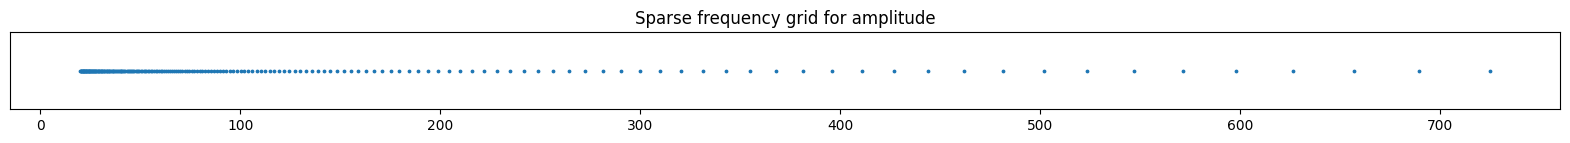

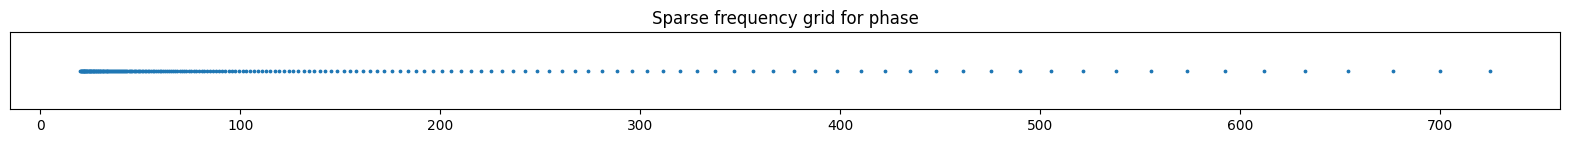

In [8]:
plt.figure(figsize=(20,1))
plt.title("Sparse frequency grid for amplitude")
plt.scatter(sparse_freq_amp, np.array([10] * len(sparse_freq_amp)), s=3)
plt.yticks([])

plt.figure(figsize=(20,1))
plt.title("Sparse frequency grid for phase")
plt.scatter(sparse_freq_phase, np.array([10] * len(sparse_freq_phase)), s=3)
plt.yticks([])

# Compute SVD and define reduced bases matrices

In [29]:
Ua, sa, Vta = np.linalg.svd(A_mat, full_matrices=False)
Up, sp, Vtp = np.linalg.svd(Phi_mat, full_matrices=False)

rank_a = 150
rank_p = 10

B_a = Ua[:, :rank_a] 
B_p = Up[:, :rank_p] 

# Interpolate projection coefficients

In [30]:
Ca = B_a.T @ A_mat
Cp = B_p.T @ Phi_mat

q_unique = np.unique(param_grid_q)
chi_unique = np.unique(param_grid_chi)

interpolants_a = []
for i in range(rank_a):
    coeff_grid = Ca[i, :].reshape(len(chi_unique), len(q_unique))
    interp = RectBivariateSpline(chi_unique, q_unique, coeff_grid, kx=3, ky=3)
    interpolants_a.append(interp)

interpolants_p = []
for i in range(rank_p):
    coeff_grid = Cp[i, :].reshape(len(chi_unique), len(q_unique))
    interp = RectBivariateSpline(chi_unique, q_unique, coeff_grid, kx=3, ky=3)
    interpolants_p.append(interp)

amp_norms_grid = np.array(amp_norms).reshape(len(chi_unique), len(q_unique))
interp_amp_norm = RectBivariateSpline(chi_unique, q_unique, amp_norms_grid, kx=3, ky=3)

# Assemble and evaluate the surrogate model

In [31]:
def evaluate_surrogate_fd(q_star, chi_star, freqs_out):
    ca_star = np.array([interp(chi_star, q_star)[0, 0] for interp in interpolants_a])
    cp_star = np.array([interp(chi_star, q_star)[0, 0] for interp in interpolants_p])

    amp_recon_sparse = B_a @ ca_star
    phase_recon_sparse = B_p @ cp_star

    spline_amp = UnivariateSpline(sparse_freq_amp, amp_recon_sparse, s=0, k=3, ext=2)
    spline_phase = UnivariateSpline(sparse_freq_phase, phase_recon_sparse, s=0, k=3, ext=2)

    amp_final = spline_amp(freqs_out)
    phase_final = spline_phase(freqs_out)

    norm_star = interp_amp_norm(chi_star, q_star)[0, 0]
    amp_final *= norm_star

    h_fd_recon = amp_final * np.exp(1j * phase_final)
    
    return freqs_out, h_fd_recon

In [32]:
test_params = {'q': 1.23, 'chi': 0.5}

true_freqs, true_h_fd = generate_fd_waveform(test_params, f_lower, delta_t, window_type=window_type, padding_type='power_of_2', epsilon=epsilon, num_extrema_start=num_extrema_start, num_extrema_end=num_extrema_end)
mask = (true_freqs >= f_min_grid) & (true_freqs <= f_max_grid)
true_freqs_masked = true_freqs[mask]
true_h_fd_masked = true_h_fd[mask]
true_amp, true_phase = get_amp_phase(true_freqs_masked, true_h_fd_masked)

surr_freqs, surr_h_fd = evaluate_surrogate_fd(test_params['q'], test_params['chi'], true_freqs_masked)

surr_amp, surr_phase = get_amp_phase(surr_freqs, surr_h_fd)

# Compute mismatch

In [33]:
pycbc_surr_h_fd = pycbc.types.FrequencySeries(surr_h_fd, delta_f=true_freqs_masked[1]-true_freqs_masked[0], epoch=0)
pycbc_true_h_fd = pycbc.types.FrequencySeries(true_h_fd_masked, delta_f=true_freqs_masked[1]-true_freqs_masked[0], epoch=0)
pycbc_surr_h_fd.start_time = 0
pycbc_true_h_fd.start_time = 0

mismatch = 1 - pycbc.filter.matchedfilter.optimized_match(pycbc_surr_h_fd, pycbc_true_h_fd, psd=pycbc.psd.aLIGOZeroDetHighPower(len(pycbc_true_h_fd), pycbc_true_h_fd.delta_f, f_lower), low_frequency_cutoff=f_min_grid)[0]
print(f"Mismatch between surrogate model and true model = {mismatch:.3e}")

Mismatch between surrogate model and true model = 1.492e-05


# Plot the results

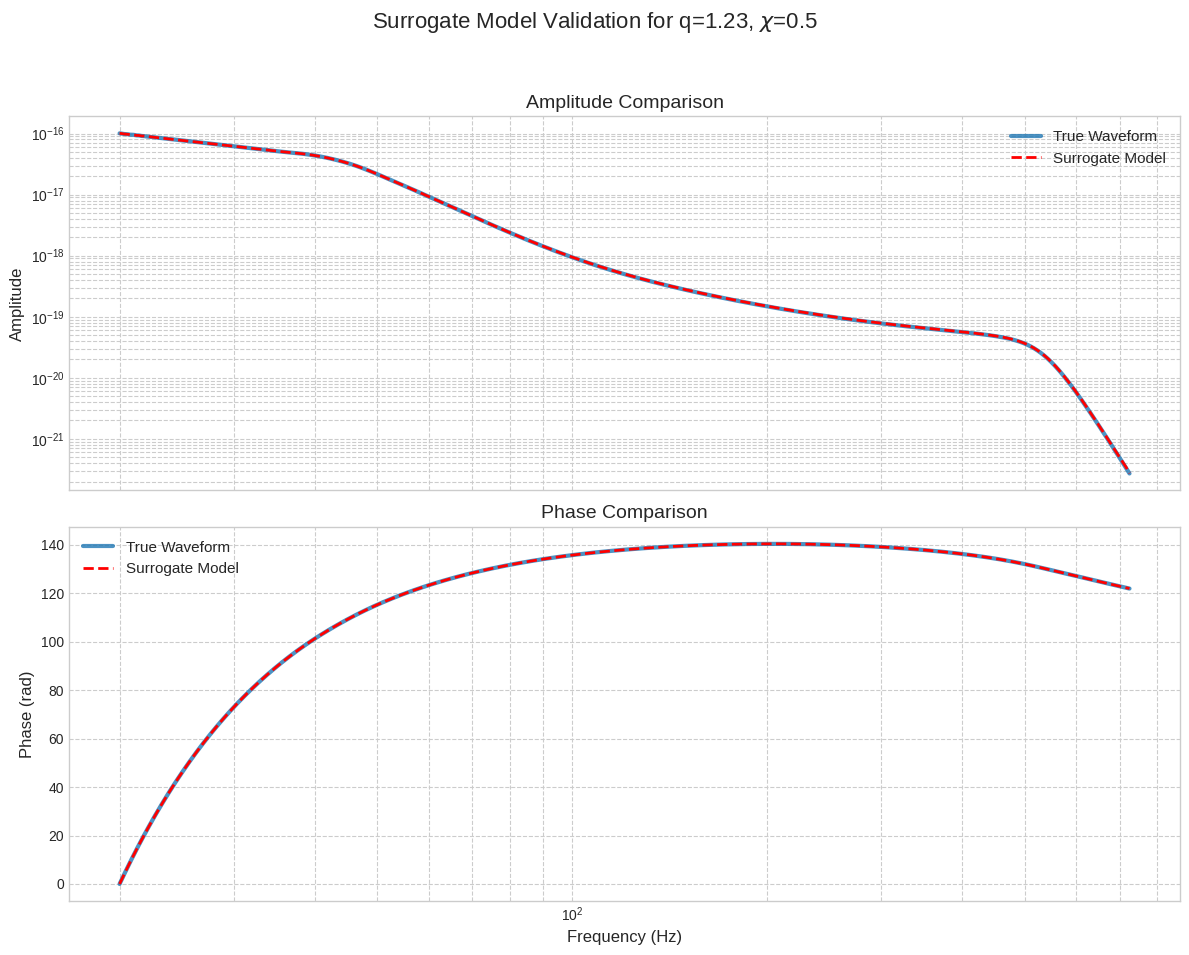

In [34]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
fig.suptitle(rf"Surrogate Model Validation for q={test_params['q']}, $\chi$={test_params['chi']}", fontsize=16)

axs[0].loglog(true_freqs_masked, true_amp, label='True Waveform', lw=3, alpha=0.8)
axs[0].loglog(surr_freqs, surr_amp, '--', label='Surrogate Model', lw=2, color='red')
axs[0].set_ylabel('Amplitude', fontsize=12)
axs[0].legend(fontsize=11)
axs[0].set_title('Amplitude Comparison', fontsize=14)
axs[0].grid(True, which="both", ls="--")

axs[1].semilogx(true_freqs_masked, true_phase, label='True Waveform', lw=3, alpha=0.8)
axs[1].semilogx(surr_freqs, surr_phase, '--', label='Surrogate Model', lw=2, color='red')
axs[1].set_xlabel('Frequency (Hz)', fontsize=12)
axs[1].set_ylabel('Phase (rad)', fontsize=12)
axs[1].legend(fontsize=11)
axs[1].set_title('Phase Comparison', fontsize=14)
axs[1].grid(True, which="both", ls="--")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Plotting the projection coefficients

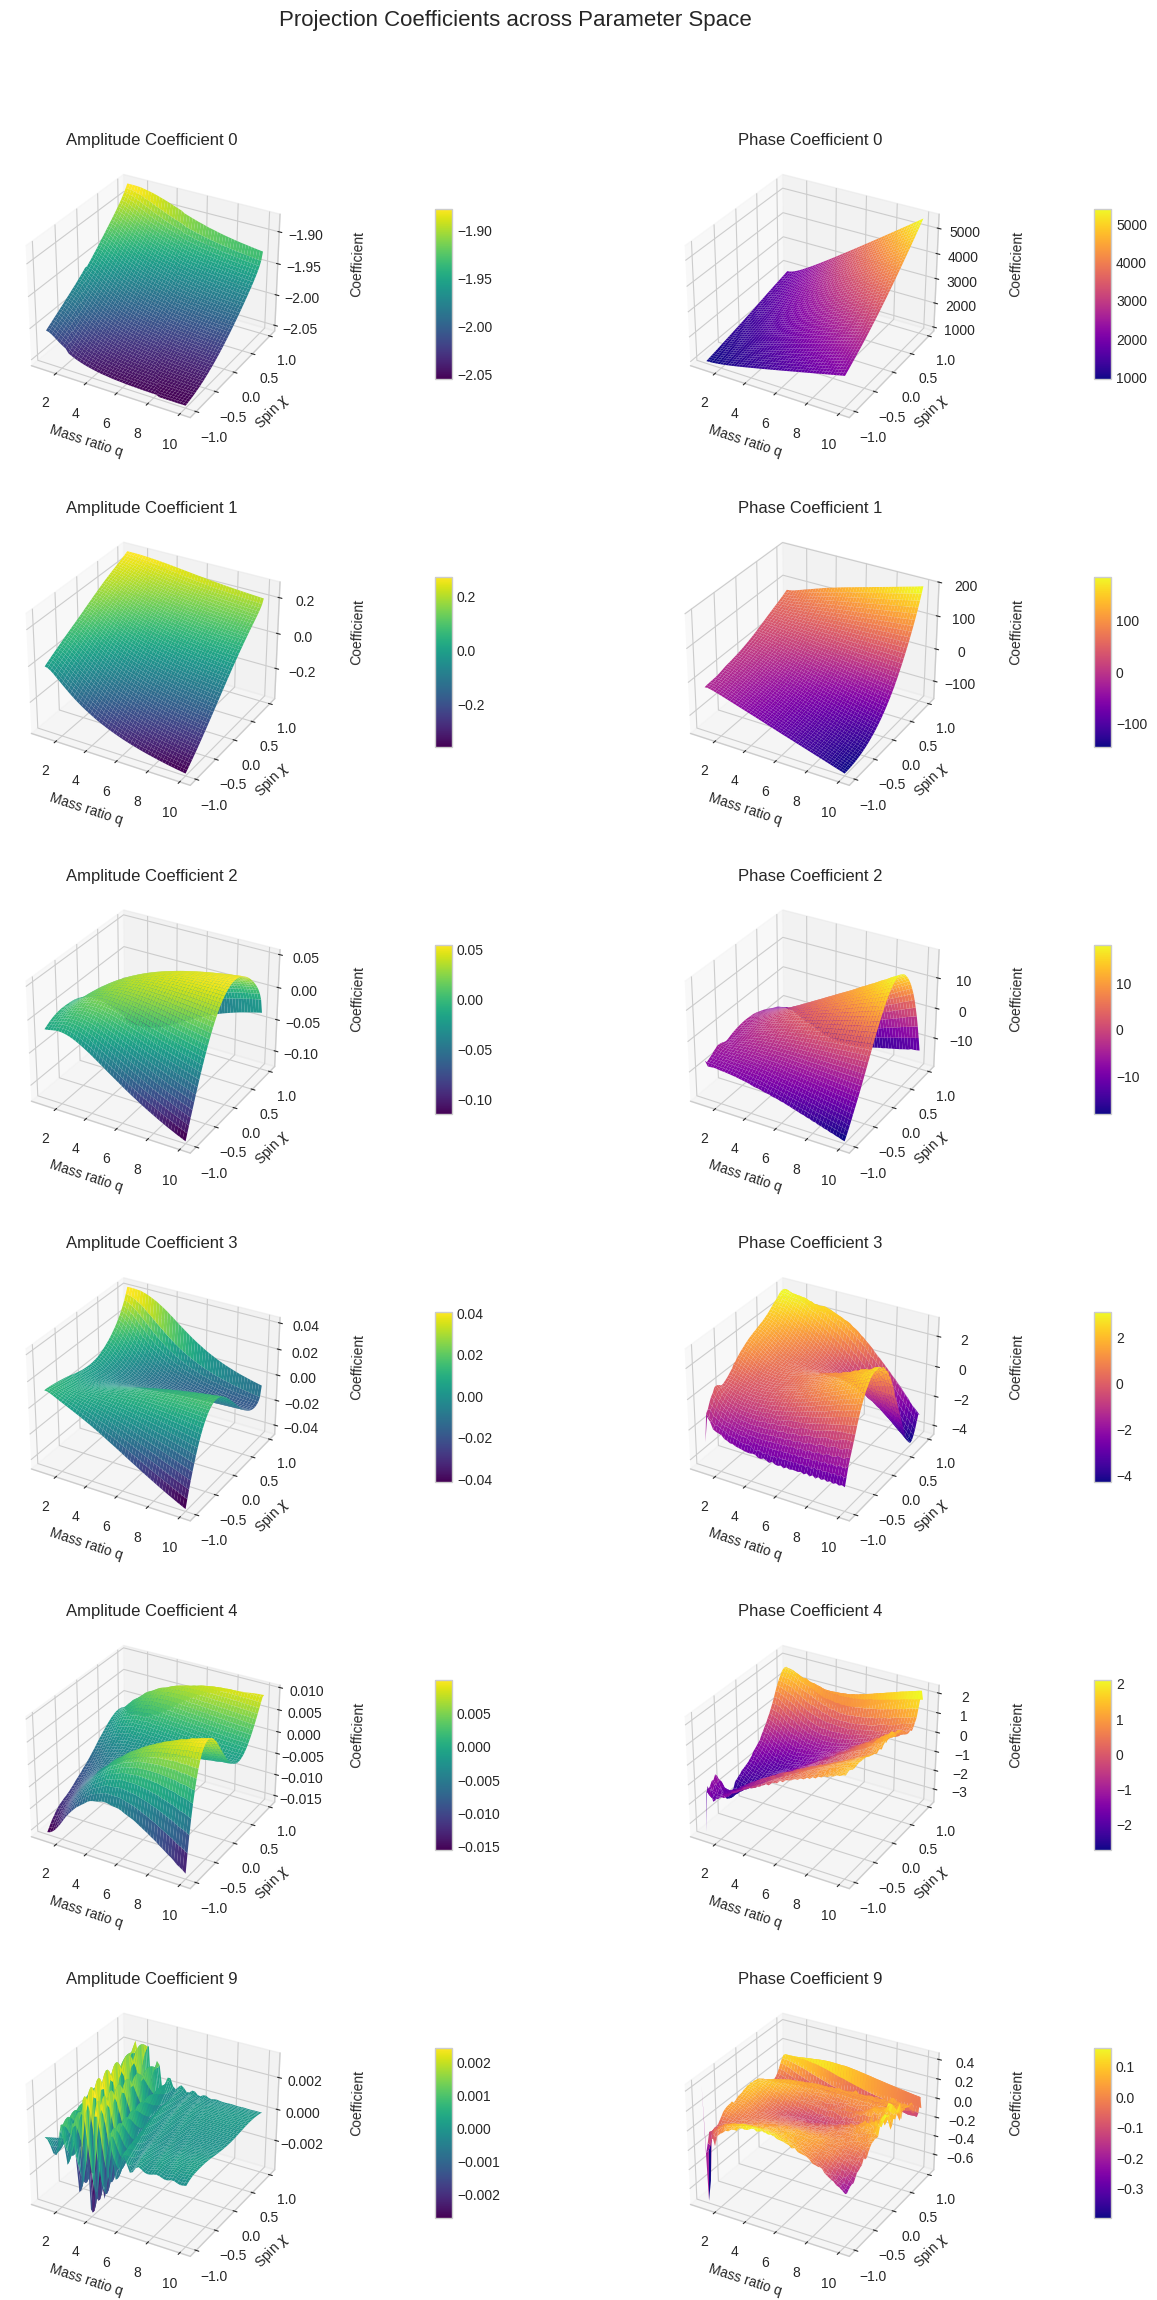

In [16]:
modes_to_plot = [0, 1, 2, 3, 4, 9]

fig = plt.figure(figsize=(14, 4*len(modes_to_plot)))
fig.suptitle("Projection Coefficients across Parameter Space", fontsize=16)

for j, mode in enumerate(modes_to_plot):

    coeff_grid_a = Ca[mode, :].reshape(len(chi_unique), len(q_unique))
    coeff_grid_p = Cp[mode, :].reshape(len(chi_unique), len(q_unique))

    Q, Chi = np.meshgrid(q_unique, chi_unique)

    ax1 = fig.add_subplot(len(modes_to_plot), 2, 2*j+1, projection='3d')
    surf_a = ax1.plot_surface(Q, Chi, coeff_grid_a, cmap="viridis", edgecolor="none")
    ax1.set_title(f"Amplitude Coefficient {mode}")
    ax1.set_xlabel("Mass ratio q")
    ax1.set_ylabel(rf"Spin $\chi$")
    ax1.set_zlabel("Coefficient")
    ax1.zaxis.labelpad = 15
    fig.colorbar(surf_a, ax=ax1, shrink=0.6, aspect=10, pad=0.2) 

    ax2 = fig.add_subplot(len(modes_to_plot), 2, 2*j+2, projection='3d')
    surf_p = ax2.plot_surface(Q, Chi, coeff_grid_p, cmap="plasma", edgecolor="none")
    ax2.set_title(f"Phase Coefficient {mode}")
    ax2.set_xlabel("Mass ratio q")
    ax2.set_ylabel(rf"Spin $\chi$")
    ax2.set_zlabel("Coefficient")
    ax2.zaxis.labelpad = 15
    fig.colorbar(surf_p, ax=ax2, shrink=0.6, aspect=10, pad=0.2) 

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.subplots_adjust(hspace=0.3)
plt.show()

# What led to better $A_0$ coefficient?

1. Lowered the waveform generation starting frequency to $f_{min} = 15 Hz$.
2. Ensured that the frequency domain waveform has extremas at $15 Hz$ and $1024 Hz$, and lowered the ROM $f_{min}$ to $20 Hz$. This also ensured that I need not extrapolate while doing cubic spline interpolation.
3. Changed power of $f$ in generating frequency sparse grid for amplitude from $1.0$ to $1.5$ which implies that more grid points are present at lower frequency band.

### What stayed same?
1. I am using the planck tapering window with same $\epsilon = 0.1$

# Plotting bases functions as a function of CSE points

In [ ]:
def plot_basis_functions(basis_matrix, freq_grid, modes_to_plot, basis_type):
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(12, 7))

    for mode in modes_to_plot:
        if mode < basis_matrix.shape[1]:
            plt.plot(freq_grid, basis_matrix[:, mode], label=f'Basis Function {mode}', lw=2)
        else:
            print(f"Warning: Mode {mode} is out of bounds for the given basis matrix.")

    plt.title(f'{basis_type} Basis Functions', fontsize=16)
    plt.xlabel('Frequency (Hz)', fontsize=12)
    plt.ylabel('Basis Function Value', fontsize=12)
    plt.xscale('log')
    plt.grid(True, which="both", ls="--")
    plt.legend()
    plt.tight_layout()
    plt.show()

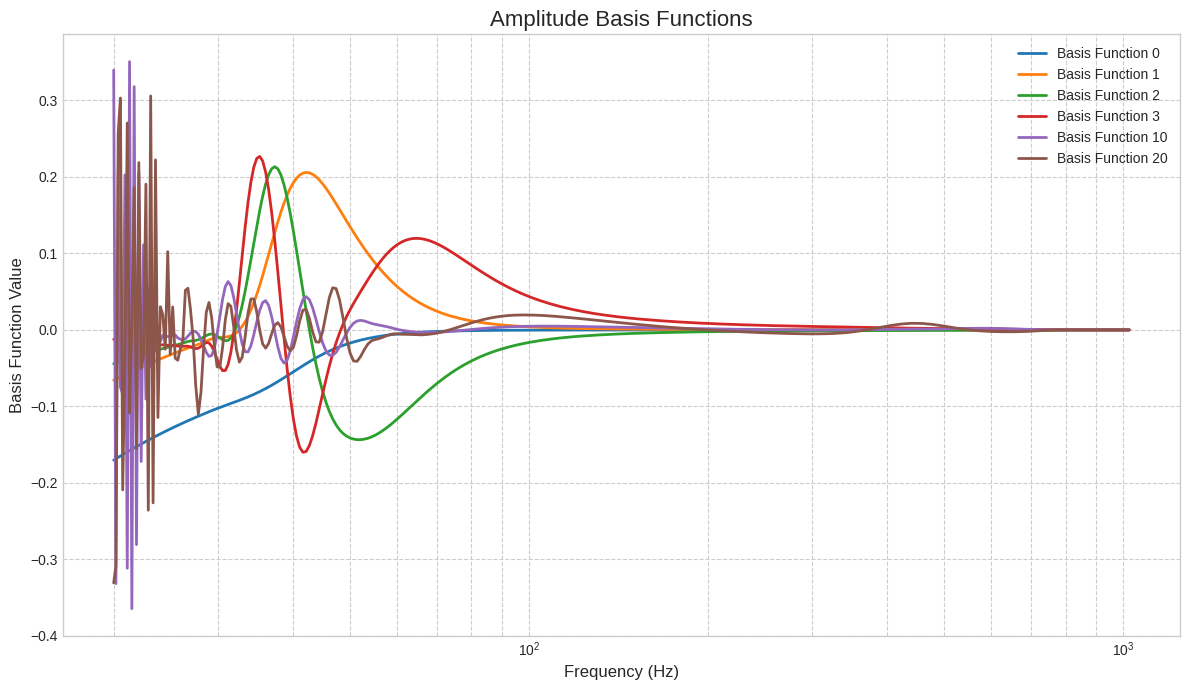

In [ ]:
plot_basis_functions(B_a, sparse_freq_amp, [0, 1, 2, 3, 10, 20], 'Amplitude')

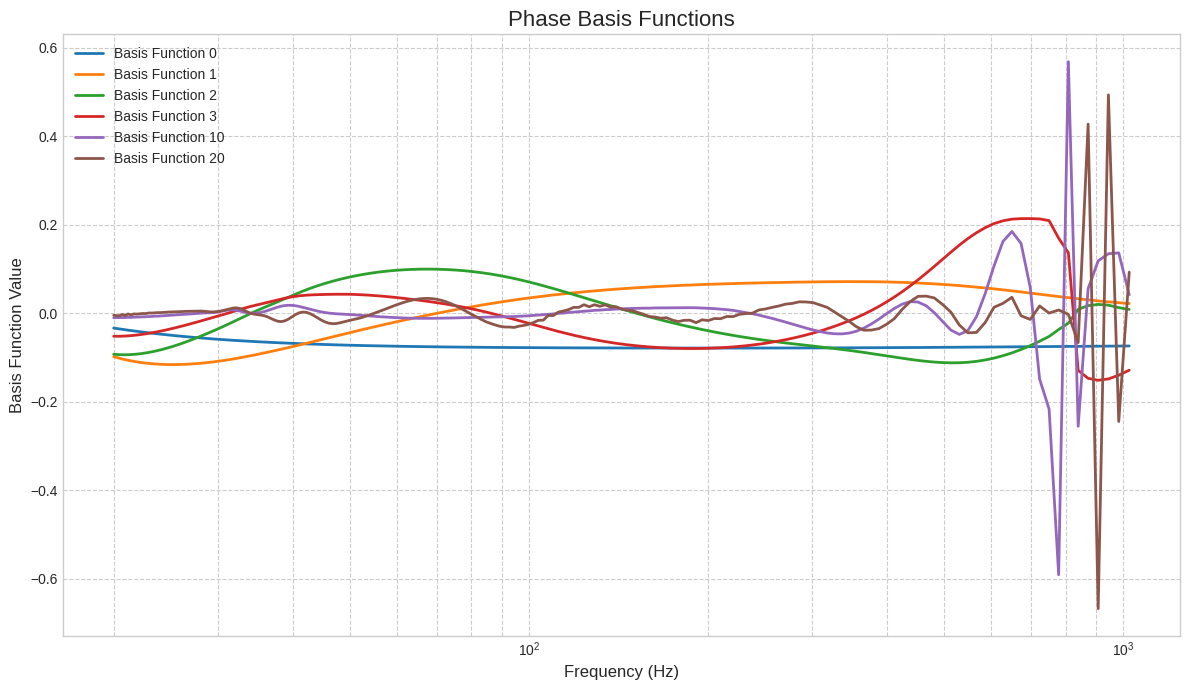

In [ ]:
plot_basis_functions(B_p, sparse_freq_phase, [0, 1, 2, 3, 10, 20], 'Phase')

# Plotting SVD eigenvalues

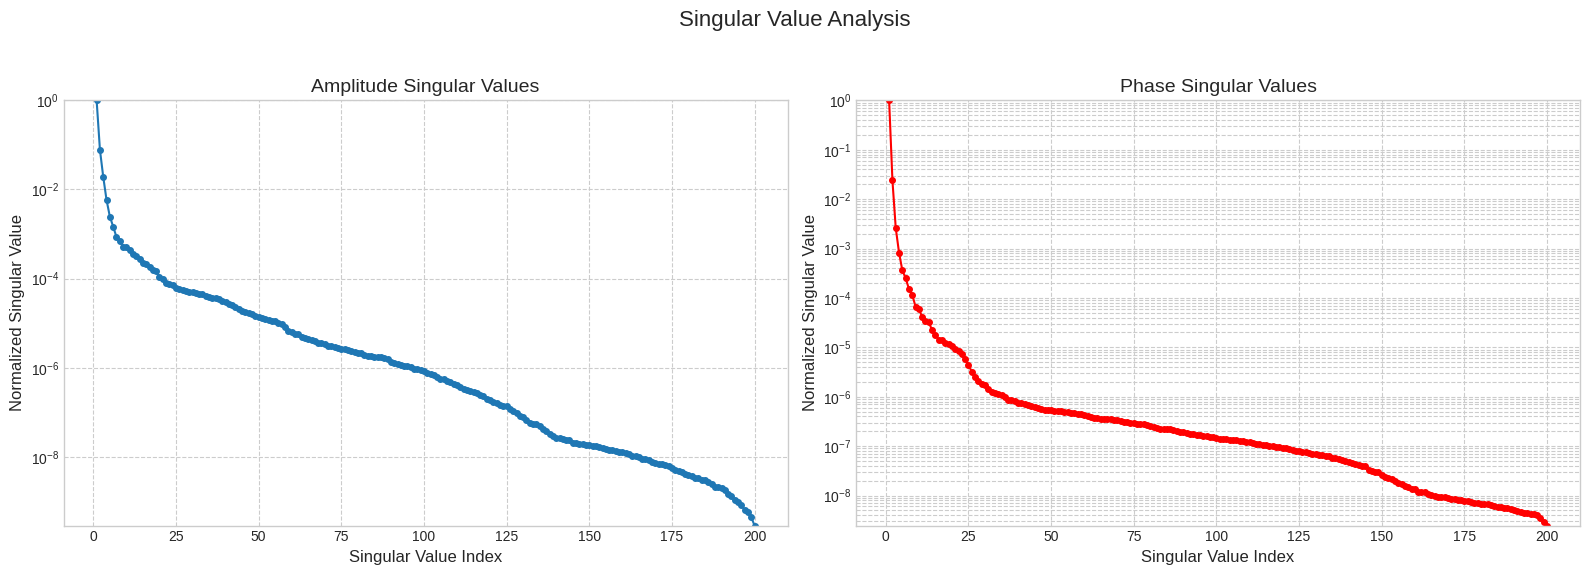

In [ ]:
def plot_normalized_singular_values(sa, sp):
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axs = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Singular Value Analysis", fontsize=16)

    normalized_sa = sa / sa[0]
    x_sa = np.arange(1, len(sa) + 1)
    axs[0].semilogy(x_sa, normalized_sa, '-o', markersize=4)
    axs[0].set_ylim(min(normalized_sa), 1.0)
    axs[0].set_title("Amplitude Singular Values", fontsize=14)
    axs[0].set_xlabel("Singular Value Index", fontsize=12)
    axs[0].set_ylabel("Normalized Singular Value", fontsize=12)
    axs[0].grid(True, which="both", ls="--")

    normalized_sp = sp / sp[0]
    x_sp = np.arange(1, len(sp) + 1)
    axs[1].semilogy(x_sp, normalized_sp, '-o', markersize=4, color='red')
    axs[1].set_ylim(min(normalized_sp), 1.0)
    axs[1].set_title("Phase Singular Values", fontsize=14)
    axs[1].set_xlabel("Singular Value Index", fontsize=12)
    axs[1].set_ylabel("Normalized Singular Value", fontsize=12)
    axs[1].grid(True, which="both", ls="--")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

plot_normalized_singular_values(sa, sp)

# Save the surrogate model

In [ ]:
def save_surrogate(filename, data):
    """Save surrogate model data to disk."""
    with open(filename, "wb") as f:
        pickle.dump(data, f)

surrogate_data = {
    "sparse_freq_amp": sparse_freq_amp,
    "sparse_freq_phase": sparse_freq_phase,
    "B_a": B_a,
    "B_p": B_p,
    "Ca": Ca,
    "Cp": Cp,
    "amp_norms_grid": amp_norms_grid,
    "q_unique": q_unique,
    "chi_unique": chi_unique
}

save_surrogate("../Models/surrogate_model.pkl", surrogate_data)
print("Surrogate model saved to surrogate_model.pkl")

Surrogate model saved to surrogate_model.pkl
